# 14 · Edge Stability under Noise

LRT4012 Robot Vision · Fall 2026


## Intensity changes and derivative operators

An edge is a localized image-intensity change. It may indicate an object boundary, texture, a shadow, or a reflection.

$$\nabla I=(I_x,I_y)^T,\quad m=\sqrt{I_x^2+I_y^2},\quad \theta=\operatorname{atan2}(I_y,I_x),\quad \nabla^2 I=I_{xx}+I_{yy}.$$

$I(x,y)$ is grayscale intensity at pixel coordinates $(x,y)$; $I_x,I_y$ are first spatial derivatives, $I_{xx},I_{yy}$ are second derivatives, $m$ is gradient magnitude, and $\theta$ is the direction of increasing intensity, normal to the edge. Image $y$ increases downward. Sobel approximates first derivatives; the Laplacian approximates the sum of second derivatives. Compute derivatives in floating point to retain negative responses.

Canny combines Gaussian smoothing, gradient estimation, non-maximum suppression along the gradient, and hysteresis. The lower threshold connects weak responses to strong responses above the upper threshold. A threshold on absolute Laplacian response is a comparison baseline, not a zero-crossing detector.


## Metric definitions

For binary prediction $A$ and reference $B$, $TP=|A\cap B|$, $FP=|A\setminus B|$, and $FN=|B\setminus A|$ count true positives, false positives, and false negatives in pixels. The symbol $|\cdot|$ denotes set size.

$$\mathrm{IoU}=\frac{TP}{TP+FP+FN},\quad P=\frac{TP}{TP+FP},\quad R=\frac{TP}{TP+FN},\quad F_1=\frac{2TP}{2TP+FP+FN}.$$

$P$ is precision and $R$ is recall. Undefined precision or recall is reported as NaN. Two empty masks have IoU and F1 equal to one by convention. A reference produced by an algorithm measures agreement with that algorithm; it is not ground truth. Synthetic labels support controlled tests, but do not establish performance on real scenes.


## Experimental protocol and files

Official images are read from `imagenes`. Personal notebooks belong in `student_work`; captured or generated images belong in `student_work/imagenes`. No cell writes to the official resource directory. Relative discovery supports a cloned course repository; `VISION_ROBOTICA_REPO` is an optional local override.

Predict the effect of each parameter before running a comparison. Keep image size and acquisition conditions fixed. Timing reports the median of 30 runs after one warm-up, excludes plotting and file access, and describes this computer only. Random generators use seed 4012. A missing detection is an experimental result, not evidence that no object exists.


In [1]:
from pathlib import Path
import os, time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_repository():
    candidates = []
    if os.environ.get('VISION_ROBOTICA_REPO'):
        candidates.append(Path(os.environ['VISION_ROBOTICA_REPO']).expanduser())
    candidates += [Path.cwd(), *Path.cwd().parents]
    for root in candidates:
        if (root / 'requirements.txt').is_file() and (root / 'imagenes').is_dir():
            return root.resolve()
    raise FileNotFoundError('Open Jupyter inside the course repository, or set VISION_ROBOTICA_REPO to its root.')

REPO = find_repository()
IMAGE_DIR = REPO / 'imagenes'  # Read-only official resources.
# Save your own notebook and generated images in student_work/ and student_work/imagenes/.
cv2.setRNGSeed(4012)
cv2.setNumThreads(1)
rng = np.random.default_rng(4012)
plt.rcParams.update({'figure.dpi':100, 'font.size':10})

def load_image(name, max_side=640):
    image = cv2.imread(str(IMAGE_DIR / name), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(f'Official resource could not be read: {name}')
    h, w = image.shape[:2]
    if max(h, w) > max_side:
        scale = max_side / max(h, w)
        image = cv2.resize(image, (round(w*scale), round(h*scale)), interpolation=cv2.INTER_AREA)
    return image

def gray(image): return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

def panels(images, titles):
    fig, axes = plt.subplots(1, len(images), figsize=(4*len(images), 3.5), squeeze=False)
    for ax, im, title in zip(axes[0], images, titles):
        if im.ndim == 3:
            ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(im, cmap='gray', vmin=0, vmax=255)
        ax.set_title(title)
        ax.axis('off')
    fig.tight_layout()
    plt.show()

def timed_ms(fn, repetitions=30):
    fn()  # Warm-up.
    times = []
    for _ in range(repetitions):
        start = time.perf_counter()
        fn()
        times.append((time.perf_counter()-start)*1000)
    return float(np.median(times))

def mask_metrics(prediction, reference):
    a, b = prediction.astype(bool), reference.astype(bool)
    tp = int(np.count_nonzero(a & b))
    fp = int(np.count_nonzero(a & ~b))
    fn = int(np.count_nonzero(~a & b))
    return {'IoU': tp/(tp+fp+fn) if tp+fp+fn else 1.0,
            'precision': tp/(tp+fp) if tp+fp else np.nan,
            'recall': tp/(tp+fn) if tp+fn else np.nan,
            'F1': 2*tp/(2*tp+fp+fn) if 2*tp+fp+fn else 1.0}


,noise,filter,operator,IoU,precision,recall,F1,density
0,Gaussian sigma=15,None,Canny,0.328,0.373,0.732,0.494,0.273
1,Gaussian sigma=15,None,Sobel,0.502,0.534,0.895,0.669,0.361
2,Gaussian sigma=15,None,Laplacian,0.311,0.342,0.778,0.475,0.530
3,Gaussian sigma=15,Gaussian,Canny,0.714,0.820,0.846,0.833,0.057
4,Gaussian sigma=15,Gaussian,Sobel,0.883,0.931,0.944,0.938,0.133
5,Gaussian sigma=15,Gaussian,Laplacian,0.676,0.786,0.829,0.807,0.017
6,Gaussian sigma=15,Median,Canny,0.490,0.687,0.630,0.657,0.049
7,Gaussian sigma=15,Median,Sobel,0.749,0.870,0.843,0.856,0.100
8,Gaussian sigma=15,Median,Laplacian,0.489,0.747,0.586,0.657,0.045
9,Impulse p=0.03,None,Canny,0.423,0.464,0.829,0.595,0.249


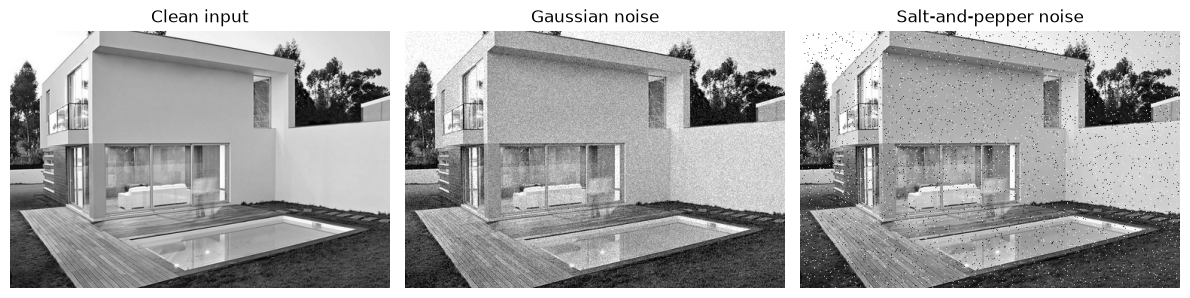

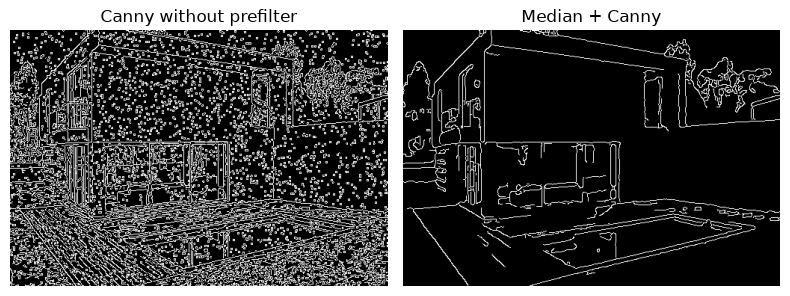

In [2]:
g = gray(load_image('casa.png'))
noisy = np.uint8(np.clip(g.astype(float)+rng.normal(0,15,g.shape),0,255))
impulse = g.copy()
u = rng.random(g.shape)
impulse[u<0.015] = 0
impulse[u>0.985] = 255
def edge_map(a, method):
    if method == 'Canny': return cv2.Canny(a,60,140,L2gradient=True)>0
    if method == 'Sobel':
        x=cv2.Sobel(a,cv2.CV_32F,1,0,ksize=3); y=cv2.Sobel(a,cv2.CV_32F,0,1,ksize=3)
        return cv2.magnitude(x,y)>100
    return np.abs(cv2.Laplacian(a,cv2.CV_32F,ksize=3))>100
rows=[]
for noise_name, noisy_image in [('Gaussian sigma=15',noisy),('Impulse p=0.03',impulse)]:
    for filter_name, filt in [('None',lambda a:a),('Gaussian',lambda a:cv2.GaussianBlur(a,(5,5),1.2)),('Median',lambda a:cv2.medianBlur(a,5))]:
        for method in ['Canny','Sobel','Laplacian']:
            reference=edge_map(filt(g),method)
            prediction=edge_map(filt(noisy_image),method)
            rows.append({'noise':noise_name,'filter':filter_name,'operator':method,
                         **mask_metrics(prediction,reference),'density':prediction.mean()})
display(pd.DataFrame(rows).round(3))
panels([g,noisy,impulse],['Clean input','Gaussian noise','Salt-and-pepper noise'])
panels([edge_map(impulse,'Canny').astype('uint8')*255,
        edge_map(cv2.medianBlur(impulse,5),'Canny').astype('uint8')*255],['Canny without prefilter','Median + Canny'])


Each operator is compared with its own clean-image output under the same prefilter. This measures stability, not the accuracy of one detector against another. Exact pixel agreement also penalizes small localization shifts.


## Robotic interpretation

Choose a filter for each noise model. Explain why a stable but empty edge map would be useless for following a painted line. For accuracy assessment, propose manually annotated boundaries and a stated pixel tolerance.


## References

- [OpenCV: image gradients](https://docs.opencv.org/4.x/d5/d0f/tutorial_py_gradients.html)
- [OpenCV: Canny](https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html)
